<center><img src='https://raw.githubusercontent.com/Jangrae/img/master/satisfaction.png'/></center>

### **고객 만족도 예측을 통한 서비스 개선**
# **단계 2: 기본 모델링**

## **미션 설명**

- 이번 단계에서는 다음과 같이 2개의 미션을 수행합니다.

### 미션 6: 전처리

- 다음과 같은 이유로 0 ~ 5 정수를 갖는 변수를 가변수화 합니다.
    - 0점은 '매우 불만족'보다 낮은 점수가 아니라 '해당 없음'을 의미하는 경우가 많습니다.
    - 만약 0, 1, 2, 3, 4, 5 그대로 넣으면, 모델은 0을 1보다 더 나쁜 것으로 학습하여 예측에 오류가 생길 수 있습니다.
    - 만족도 1점과 2점의 차이가 4점과 5점의 차이와 물리적으로 동일하지 않습니다.
    - 가변수화를 하면 모델이 각 점수를 독립적으로 학습할 수 있어 더 유연한 모델이 될 것입니다.
- 모델링을 위해 x, y로 분리하고 학습용/검증용 데이터로 분리합니다.
- 스케일링을 수행합니다.

### 미션 7: 모델링

- 4개 이상의 딥러닝 모델을 만들어 성능을 확인합니다.
- 모델 이름은 model1, model2, model3, model4...로 구분합니다.
- 마지막 모델의 경우 예측 성능을 높이기 위해 다양한 시도를 해봅니다.
- 가장 성능이 좋은 모델을 저장합니다.

## **※ 코드 셀은 충분히 추가해 사용합니다.**

## **1. 환경설정**

### (1) 구글 드라이브 연결 및 경로 설정

- 다음 구문을 실행에 구글 코랩에서 사용 가능하게 연결합니다.

In [ ]:
# 구글 드라이브 연결 & 패스 지정
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    path = '/content/drive/MyDrive/project01/'
else:
    path = ''

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### (2) 라이브러리 불러오기

- 이후에 사용할 라이브러리를 모두 불러옵니다.

In [ ]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import *

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.backend import clear_session
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


import joblib
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format='retina'

### (3) 학습 곡선 시각화 함수 만들기

- 모델링 수행 시 학습 상황을 시각화해 확인하기 위한 함수를 만듭니다.

In [ ]:
# 함수 만들기
def dl_history_plot(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history['loss'], label='Train Loss', marker='.')
    plt.plot(history['val_loss'], label='Validation Loss', marker='.')

    plt.title('Learning Curve', size=15, pad=20)
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()

### (4) 데이터 불러오기

- 이전 과정에서 저장한 파일을 읽어와 **data** 데이터프레임을 만듭니다.
    - path + 'data.csv' --> data
    

In [ ]:
# 파일 읽어오기
data = pd.read_csv(path + 'data.csv')

In [ ]:
# 크기(행, 열) 확인
print(data.shape)

(19278, 23)


## **2. 미션 6: 전처리**

- 결측치 처리는 이전 과정에서 완료가 된 상태입니다.
- 딥러닝 모델링을 위해 필요한 전처리를 수행합니다.

### (1) 가변수화

- 0 ~ 5 정수를 갖는 변수를 가변수화 합니다.
- 대상 변수는 'Inflight wifi service'부터 'Cleanliness'까지 14개 입니다.
- 일관된 가변수화 결과를 위해 Category 형 변수로 변환합니다.

In [ ]:
# 설문 범주 정의
categories = [0, 1, 2, 3, 4, 5]

# 가변수화 대상 변수
dumm_cols = ['Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location',
             'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service',
             'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness']

# Category 형 변수로 변환
for col in dumm_cols:
    data[col] = pd.Categorical(data[col], categories=categories)

# 가변수화
data = pd.get_dummies(data, columns=dumm_cols, drop_first=False, dtype=int)

# 확인
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19278 entries, 0 to 19277
Data columns (total 93 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Gender                               19278 non-null  int64  
 1   Customer Type                        19278 non-null  int64  
 2   Age                                  19278 non-null  float64
 3   Type of Travel                       19278 non-null  int64  
 4   Class                                19278 non-null  int64  
 5   Flight Distance                      19278 non-null  int64  
 6   Departure Delay in Minutes           19278 non-null  int64  
 7   Arrival Delay in Minutes             19278 non-null  float64
 8   Satisfaction                         19278 non-null  int64  
 9   Inflight wifi service_0              19278 non-null  int64  
 10  Inflight wifi service_1              19278 non-null  int64  
 11  Inflight wifi service_2     

### (2) 데이터 분할

- x, y를 분리한 후 학습용/검증용 데이터를 8:2로 분리합니다.

In [ ]:
target = 'Satisfaction'

x = data.drop(target, axis=1)
y = data[target]

In [ ]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

### (3) 스케일링

- MinMaxScaler()를 사용해 스케일링을 수행합니다.

In [ ]:
# 데이터의 범위를 일정하게 맞추고 싶다면 정규화
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)

## **3. 미션 7: 모델링**

- 다음과 같이 4개 이상의 모델을 만들고 성능을 확인합니다.
    - 모델 1: Base line 모델(Hidden Layer 없이 모델 생성)
    - 모델 2: 복잡한 모델 생성(최소 5개 이상의 Hidden Layer 추가)
    - 모델 3 ~ n: 모델 튜닝(학습률, epoch 조정, Dropout, Early Stopping 등 모델 성능을 높이기 위한 다양한 시도)


### (1) 모델 1

- 우선 모델을 선언합니다.

In [ ]:
clear_session()

nfeatures = x.shape[1]

model1 = Sequential([
    Input(shape=(nfeatures, )),
    Dense(1, activation='sigmoid')
])

model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            93 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93 (372.00 B)

 Trainable params: 93 (372.00 B)

 Non-trainable params: 0 (0.00 B)

- 학습 방법을 설정하고 학습을 수행합니다.

In [ ]:
model1.compile(optimizer=Adam(learning_rate=0.01), loss='binary_crossentropy' )

In [ ]:
hist = model1.fit(x_train, y_train, epochs=100, validation_split=0.2, batch_size=64, verbose=0).history

- 학습 곡선을 확인합니다.

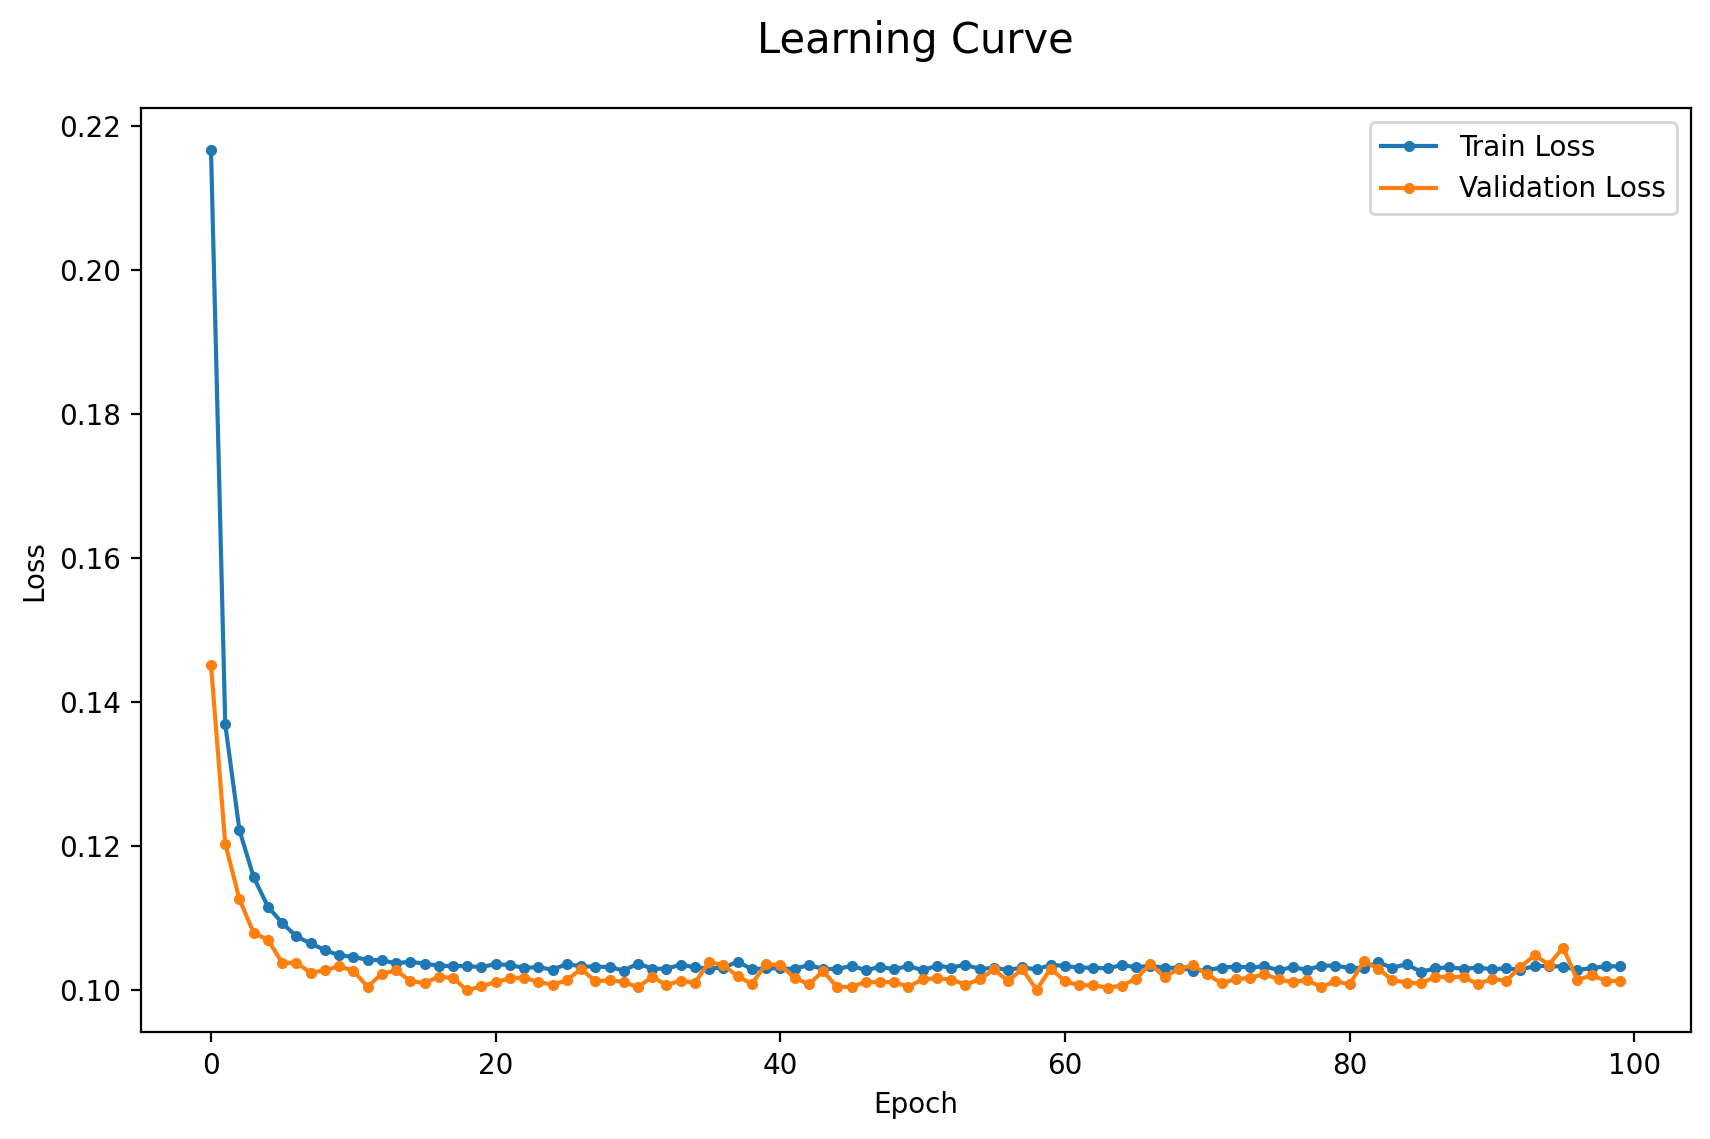

In [ ]:
dl_history_plot(hist)

- 검증 데이터로 예측 및 평가를 수행합니다.

In [ ]:
y_pred = model1.predict(x_val)
y_pred = np.where(y_pred >= 0.5, 1, 0)

121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.75      0.80       397
           1       0.97      0.98      0.98      3459

    accuracy                           0.96      3856
   macro avg       0.91      0.87      0.89      3856
weighted avg       0.96      0.96      0.96      3856



### (2) 모델 2

- 모델을 선언합니다.

In [ ]:
clear_session()

nfeatures = x.shape[1]

model2 = Sequential([
    Input(shape=(nfeatures, )),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid'),

])

model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        11,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,913 (89.50 KB)

 Trainable params: 22,913 (89.50 KB)

 Non-trainable params: 0 (0.00 B)

- 학습 방법을 설정하고 학습을 수행합니다.

In [ ]:
model2.compile(optimizer=Adam(learning_rate=0.01), loss='binary_crossentropy' )

In [ ]:
hist = model2.fit(x_train, y_train, epochs=100, validation_split=0.2, batch_size=64, verbose=0).history

- 학습 곡선을 확인합니다.

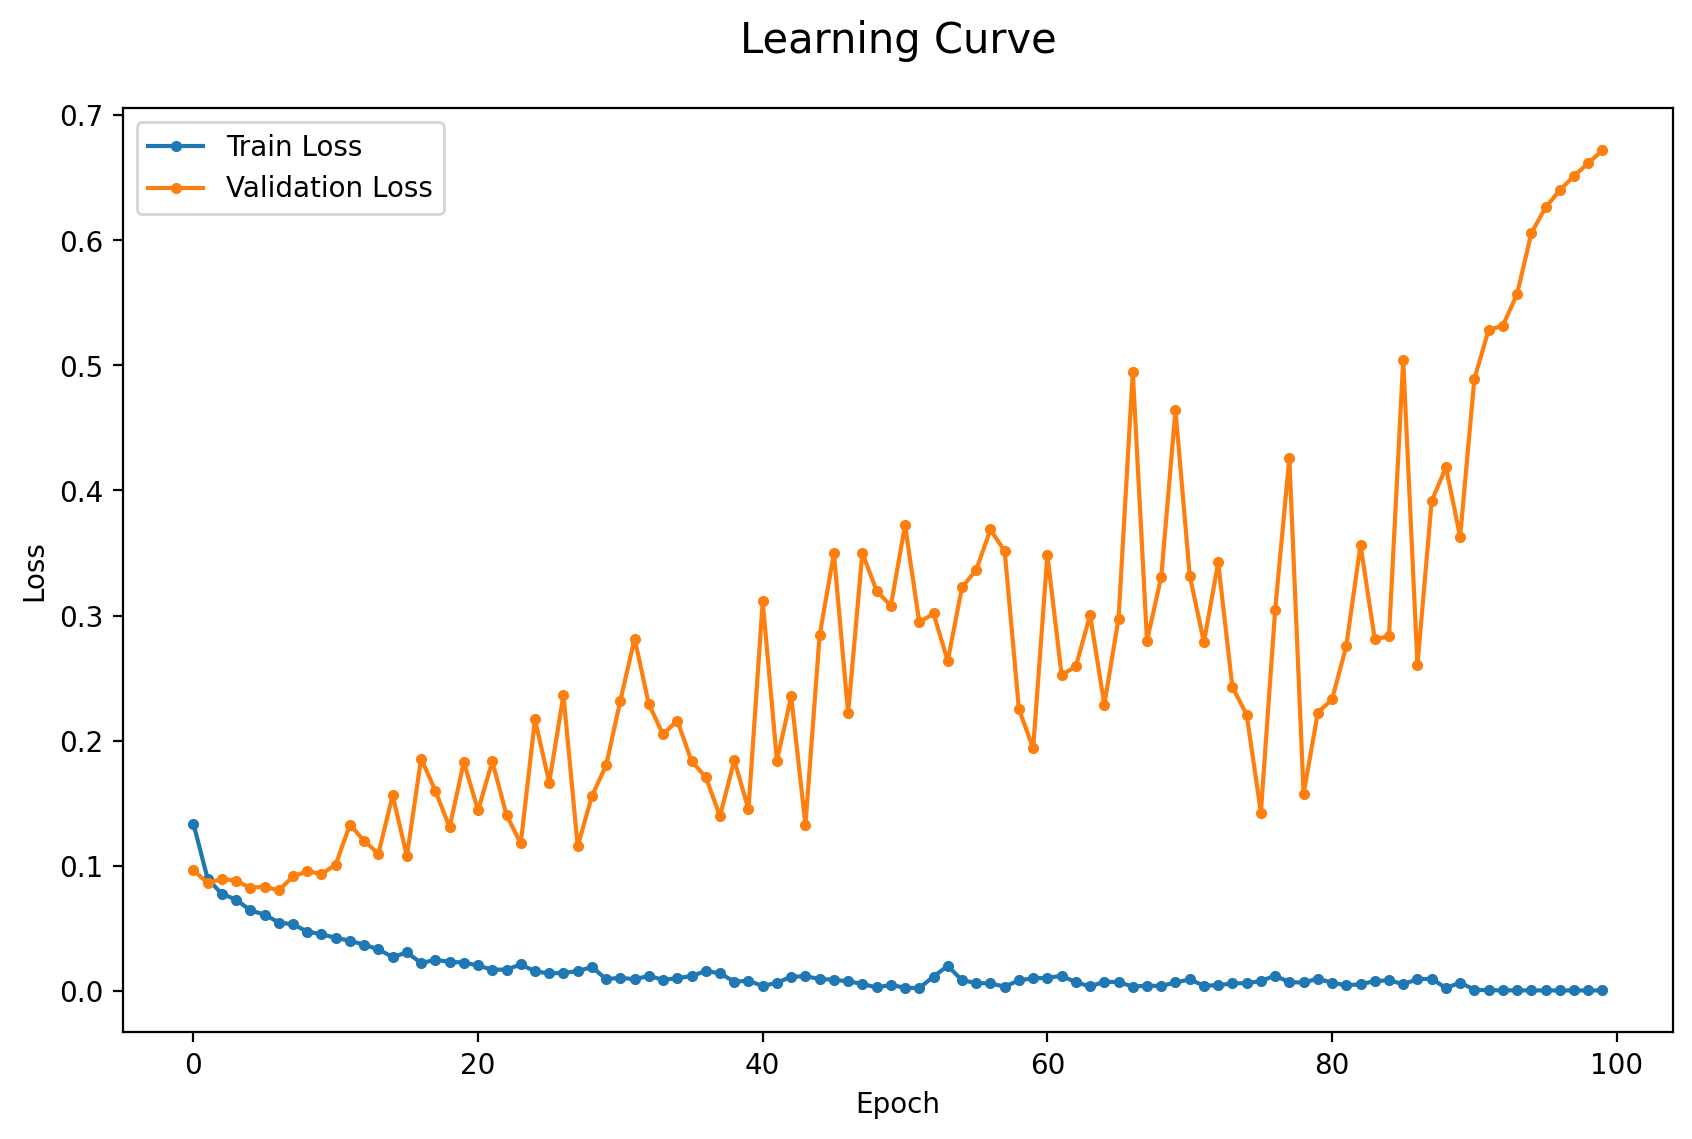

In [ ]:
dl_history_plot(hist)

- 검증 데이터로 예측 및 평가를 수행합니다.

In [ ]:
y_pred = model2.predict(x_val)
y_pred = np.where(y_pred >= 0.5, 1, 0)

121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.85      0.85       397
           1       0.98      0.98      0.98      3459

    accuracy                           0.97      3856
   macro avg       0.91      0.92      0.92      3856
weighted avg       0.97      0.97      0.97      3856



### (3) 모델 3: Dropout

- 모델을 선언합니다.

In [ ]:
clear_session()

nfeatures = x_train.shape[1]

model3 = Sequential([
    Input(shape=(nfeatures,)),


    Dense(128, activation='relu'),
    Dropout(0.3),


    Dense(64, activation='relu'),
    Dropout(0.3),


    Dense(32, activation='relu'),
    Dropout(0.2),


    Dense(16, activation='relu'),
    Dropout(0.1),
    Dense(8, activation='relu'),


    Dense(1, activation='sigmoid')
])

model3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        11,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,913 (89.50 KB)

 Trainable params: 22,913 (89.50 KB)

 Non-trainable params: 0 (0.00 B)

- 학습 방법을 설정하고 학습을 수행합니다.

In [ ]:
model3.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy')

In [ ]:
hist = model3.fit(x_train, y_train, epochs=150, validation_split=0.2, batch_size=64, verbose=0).history

- 학습 곡선을 확인합니다.

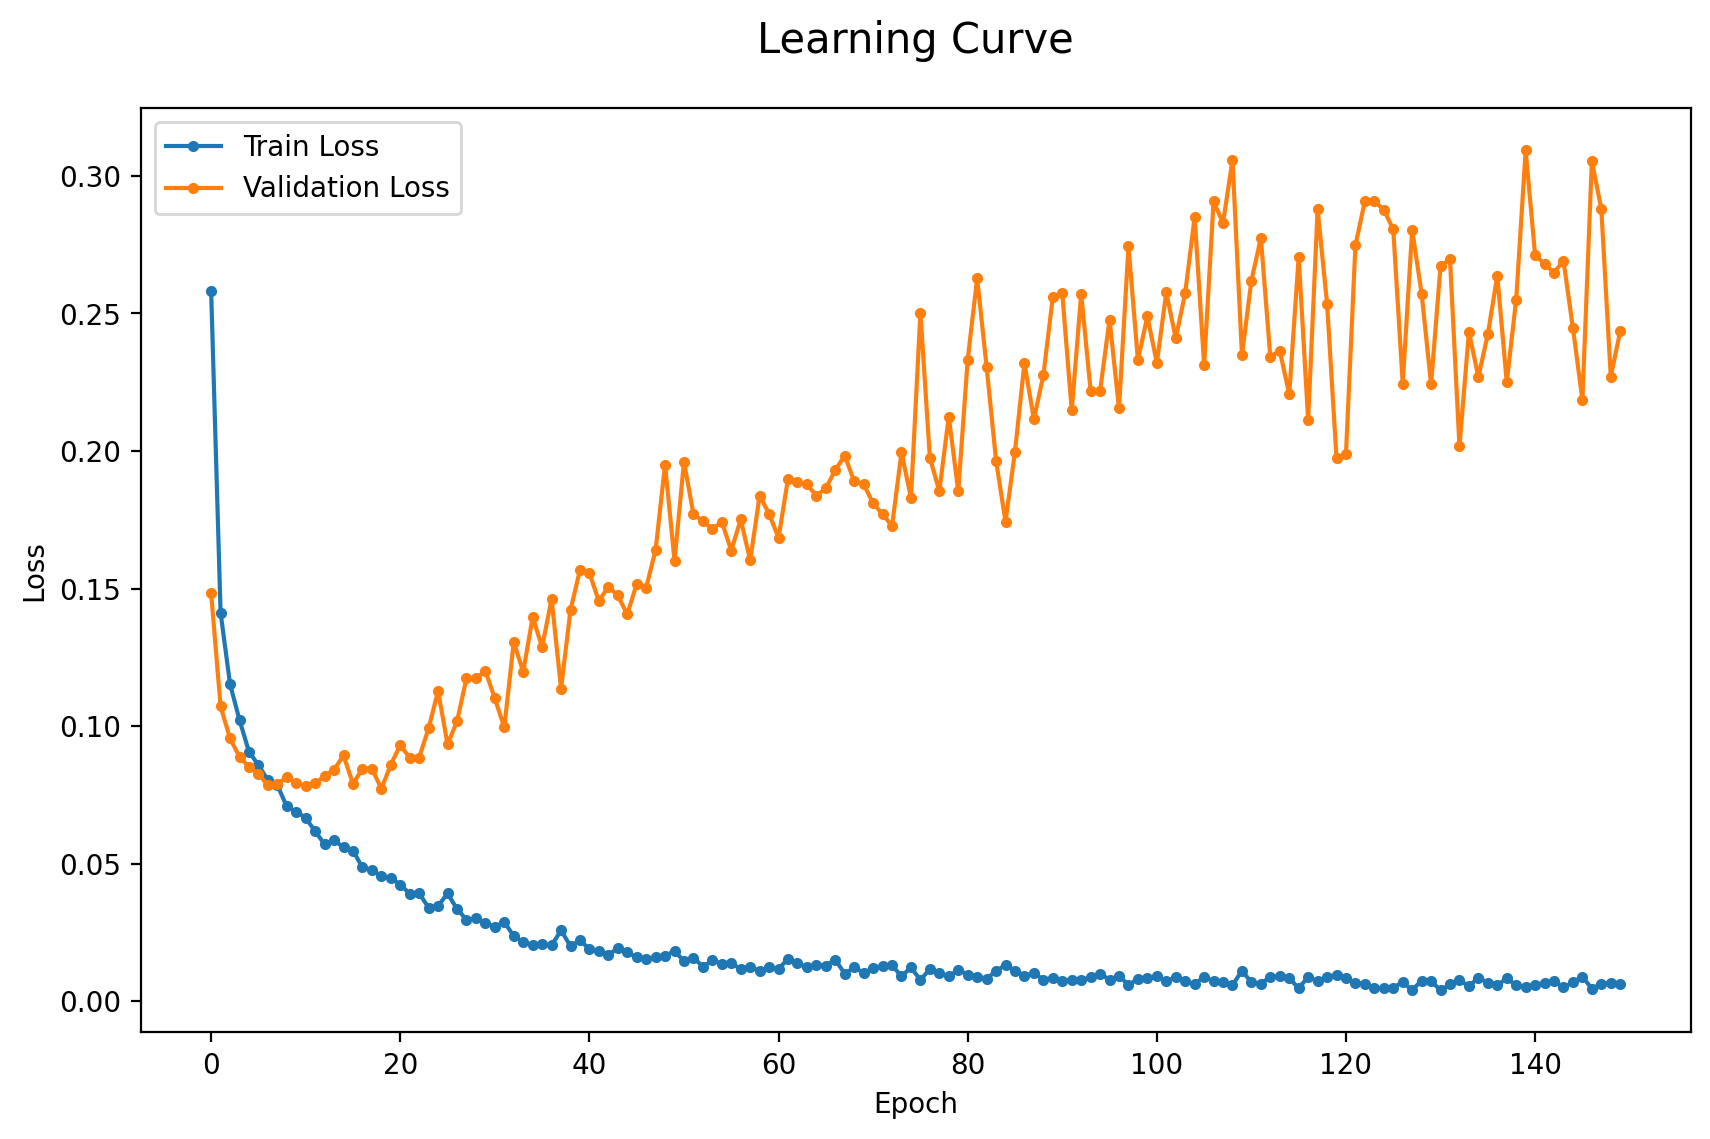

In [ ]:
dl_history_plot(hist)

- 검증 데이터로 예측을 수행하고 성능을 확인합니다.

In [ ]:
y_pred = model3.predict(x_val)
y_pred = np.where(y_pred >= 0.5, 1, 0)

121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.82      0.84       397
           1       0.98      0.99      0.98      3459

    accuracy                           0.97      3856
   macro avg       0.92      0.90      0.91      3856
weighted avg       0.97      0.97      0.97      3856



### (4) 모델 4: Early Stopping

- 모델을 선언합니다.

In [ ]:
# 가변수화(92개)가 완료된 x, y를 다시 분할
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter
# 1. SMOTE 오버샘플링 적용
smote = SMOTE(random_state=42)
x_train_over, y_train_over = smote.fit_resample(x_train, y_train)

print("Original:", Counter(y_train))
print("After SMOTE:", Counter(y_train_over))

Original: Counter({1: 13834, 0: 1588})
After SMOTE: Counter({0: 13834, 1: 13834})


In [ ]:
scaler = MinMaxScaler()
x_train_over = scaler.fit_transform(x_train_over) # 0~1로 예쁘게 압축됨

# 검증용 데이터도 새로운 스케일러 기준에 맞춰 변환
x_val = scaler.transform(x_val)

In [ ]:
# 메모리 정리
clear_session()

# 입력 Feature 수
nfeatures = x.shape[1]

# Sequential 모델 선언
model4 = Sequential([
    Input(shape=(nfeatures,)),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(16, activation='relu'),

    Dense(1, activation='sigmoid')
])

# 모델 요약
model4.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         5,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,961 (35.00 KB)

 Trainable params: 8,769 (34.25 KB)

 Non-trainable params: 192 (768.00 B)

- 학습 방법을 설정하고 학습을 수행합니다.
- 개인적으로 오버샘플링을 해서 결과를 보고자함

In [ ]:
model4.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
es = EarlyStopping(monitor='val_loss',
                   min_delta=0,
                   patience=10,
                   restore_best_weights=True,
                   verbose=1)

In [ ]:
hist = model4.fit(x_train_over, y_train_over, epochs=100, validation_data=(x_val, y_val), batch_size=64, callbacks=[es], verbose=0).history

Epoch 28: early stopping
Restoring model weights from the end of the best epoch: 18.


- 학습 곡선을 확인합니다.

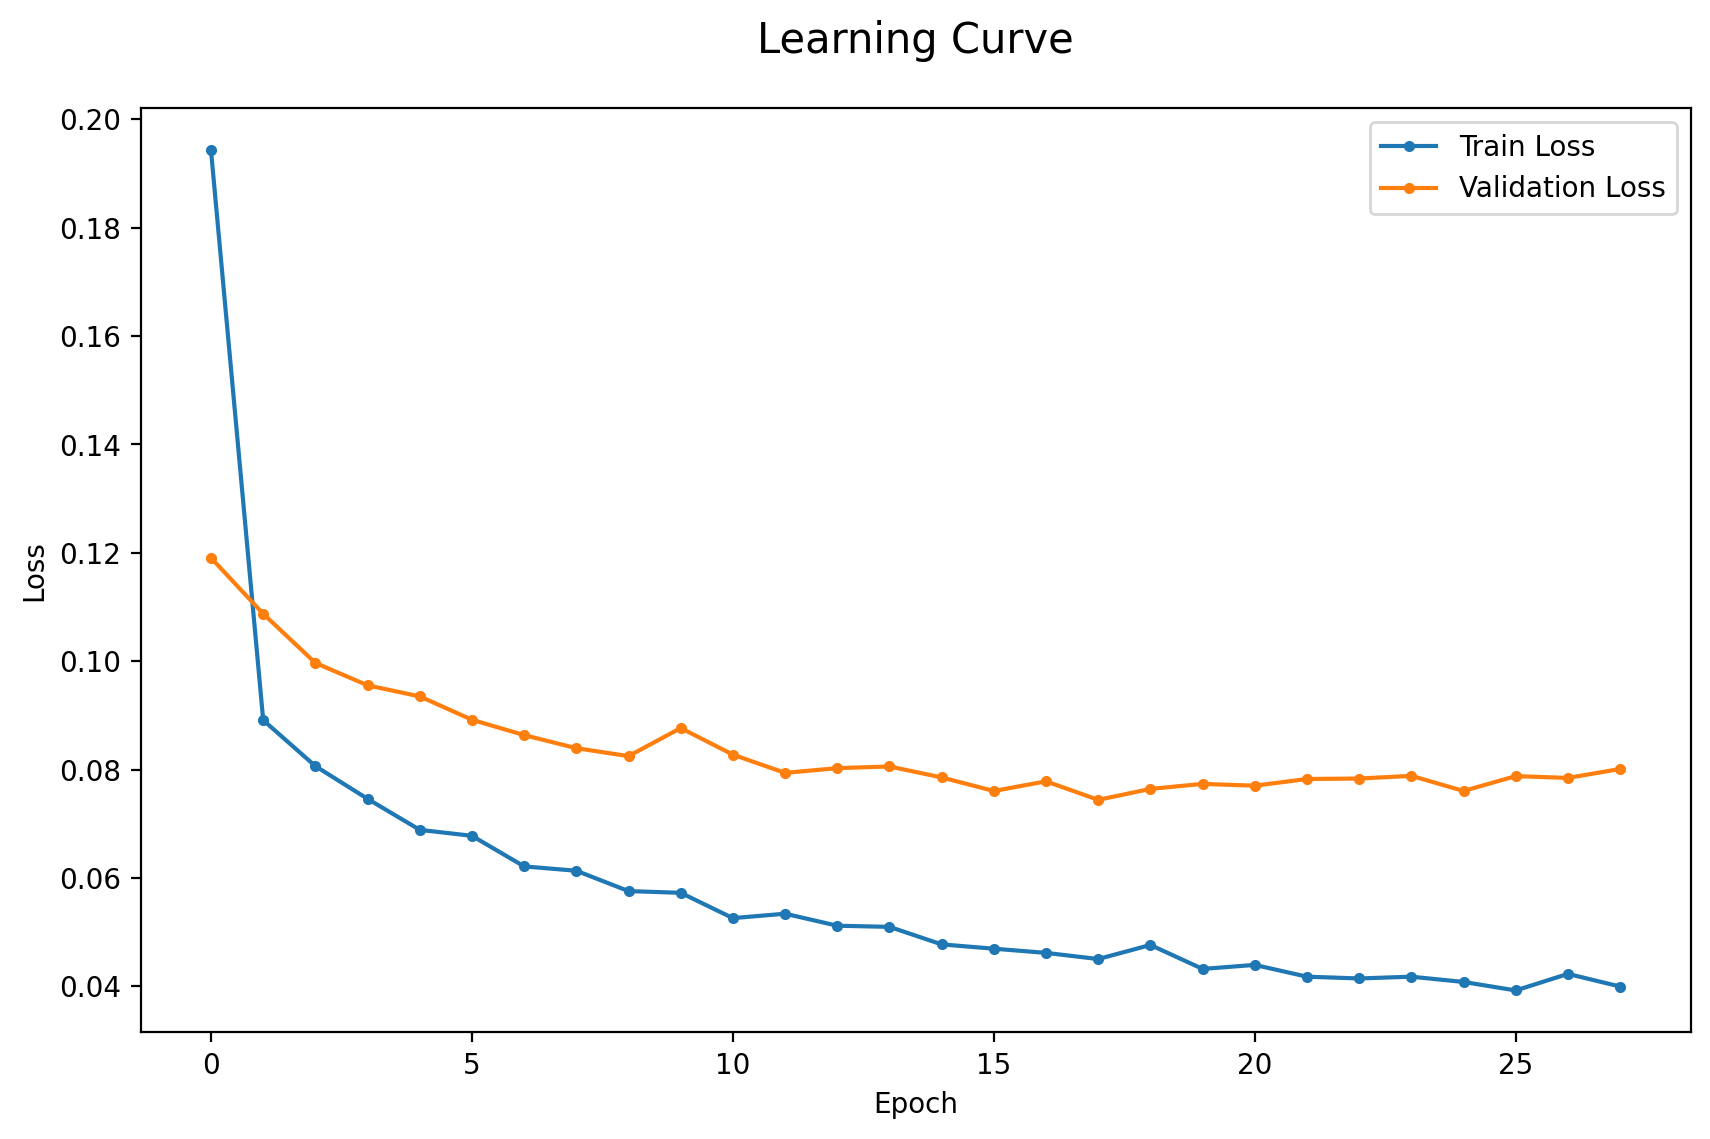

In [230]:
dl_history_plot(hist)

- 검증 데이터로 예측 및 평가를 수행합니다.

In [231]:
y_pred = model4.predict(x_val)
y_pred = np.where(y_pred >= 0.5, 1, 0)

121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [232]:
# 오버 샘플링 한 후 결과

print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.83      0.85       397
           1       0.98      0.99      0.98      3459

    accuracy                           0.97      3856
   macro avg       0.93      0.91      0.92      3856
weighted avg       0.97      0.97      0.97      3856



오버 샘플링 하기 전 결과

                  precision    recall  f1-score   support

           0       0.87      0.80      0.83       397
           1       0.98      0.99      0.98      3459

    accuracy                           0.97      3856
    macro avg       0.92      0.89      0.91      3856
    weighted avg       0.97      0.97      0.97      3856


In [ ]:
# 의견 : 본 모델은 SMOTE 오버샘플링 적용을 통해 불만족 고객(Class 0)에 대한 재현율(Recall)을 80%에서 83%로 개선하는 데 성공하였습니다.
#        본 분석에서 오버샘플링(SMOTE)을 실시한 이유는 클래스 불균형에 따른 모델의 편향성을 해소하기 위함입니다. 다수 클래스인 '만족' 데이터의 손실을 방지하면서도,
#        소수 클래스인 '불만족' 데이터의 특징을 충분히 학습시켜 실제 비즈니스 가치가 높은 불만족 고객 탐지 성능(Recall)을 극대화하고자 하였습니다

### (5) 저장

- 학습용 데이터 스케일링에 사용한 스케일러를 **scaler.pkl** 파일로 저장합니다.
- **joblib.dump()** 함수를 사용합니다.

In [ ]:
# 스케일러 저장
joblib.dump(scaler, path + 'scaler.pkl')

['/content/drive/MyDrive/project01/scaler.pkl']

- 성능이 가장 높은 모델을 **base_model.keras** 파일로 저장합니다.
- **save()** 메서드를 사용합니다.

In [ ]:
# 모델 저장
model4.save(path + 'base_model.keras')